<a href="https://colab.research.google.com/github/kalyankargouri/Deep-Learning/blob/main/DLexper6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.6907 - loss: 0.5670 - val_accuracy: 0.8142 - val_loss: 0.4342
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.8123 - loss: 0.4117 - val_accuracy: 0.7408 - val_loss: 0.5348
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8984 - loss: 0.2530 - val_accuracy: 0.8046 - val_loss: 0.4766
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.9362 - loss: 0.1590 - val_accuracy: 0.6236 - val_loss: 0.6626
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9071 - loss: 0.2257 - val_accuracy: 0.7864 - val_loss: 0.6105
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.9867 - loss: 0.0417 - val_accuracy: 0.7364 - val_loss: 0.8682
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9985 - loss: 0.0098 - val_accuracy: 0.7298 - val_loss: 0.9835
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.9999 - loss: 0.0027 - val_accura

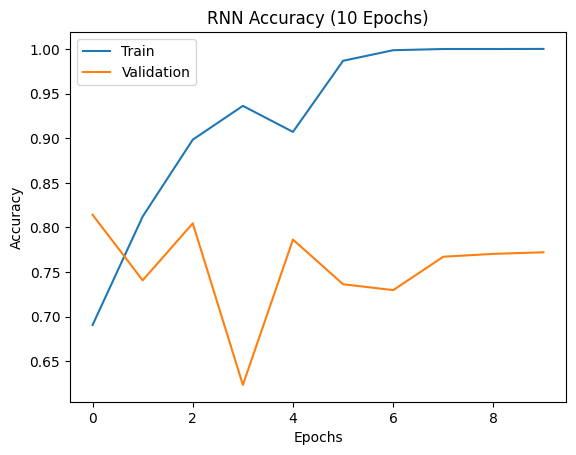

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (UPDATED: epochs=10)
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("RNN Accuracy:", acc)

# Predictions
predictions = model.predict(x_test)
for i in range(5):
    print(predictions[i][0], "->", "Positive" if predictions[i][0] > 0.5 else "Negative", "| Actual:", y_test[i])

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('RNN Accuracy (10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 243ms/step - accuracy: 0.7848 - loss: 0.4433 - val_accuracy: 0.8594 - val_loss: 0.3320
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 241ms/step - accuracy: 0.9025 - loss: 0.2509 - val_accuracy: 0.8532 - val_loss: 0.3456
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 237ms/step - accuracy: 0.9294 - loss: 0.1877 - val_accuracy: 0.8366 - val_loss: 0.3953
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 236ms/step - accuracy: 0.9489 - loss: 0.1402 - val_accuracy: 0.8628 - val_loss: 0.3736
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - accuracy: 0.9606 - loss: 0.1096 - val_accuracy: 0.8566 - val_loss: 0.4033
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.9708 - loss: 0.0878 - val_accuracy: 0.8452 - val_loss: 0.4702
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.9690 - loss: 0.0843 - val_accuracy: 0.8604 - val_loss: 0.5320
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - accuracy: 0.9809 - loss: 0

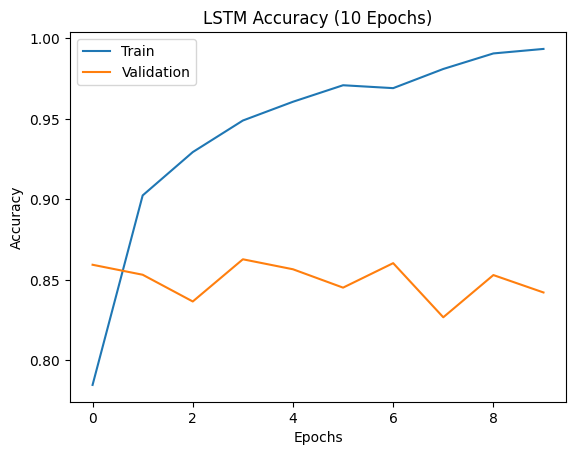

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (UPDATED: epochs=10)
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("LSTM Accuracy:", acc)

# Predictions
predictions = model.predict(x_test)
for i in range(5):
    print(predictions[i][0], "->", "Positive" if predictions[i][0] > 0.5 else "Negative", "| Actual:", y_test[i])

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Accuracy (10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 261ms/step - accuracy: 0.7782 - loss: 0.4453 - val_accuracy: 0.8642 - val_loss: 0.3296
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 282ms/step - accuracy: 0.9003 - loss: 0.2505 - val_accuracy: 0.8768 - val_loss: 0.3209
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 263ms/step - accuracy: 0.9301 - loss: 0.1831 - val_accuracy: 0.8620 - val_loss: 0.3284
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 267ms/step - accuracy: 0.9589 - loss: 0.1163 - val_accuracy: 0.8702 - val_loss: 0.4048
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 265ms/step - accuracy: 0.9759 - loss: 0.0720 - val_accuracy: 0.8368 - val_loss: 0.4728
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9837 - loss: 0.0524 - val_accuracy: 0.8676 - val_loss: 0.4949
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.9875 - loss: 0.0382 - val_accuracy: 0.8670 - val_loss: 0.5440
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.9958 - loss:

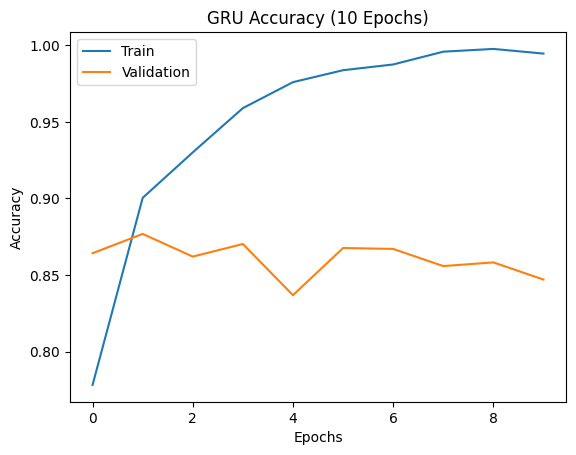

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (UPDATED: epochs=10)
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("GRU Accuracy:", acc)

# Predictions
predictions = model.predict(x_test)
for i in range(5):
    print(predictions[i][0], "->", "Positive" if predictions[i][0] > 0.5 else "Negative", "| Actual:", y_test[i])

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('GRU Accuracy (10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()